# Nudge Timing Analysis

One chart: sessions as horizontal bars on a timeline, with notification markers overlaid. Instantly shows whether a nudge preceded a session.

## 1 — Imports & config

In [27]:
import os
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from dotenv import load_dotenv
import sqlalchemy

ROOT = Path.cwd()
if ROOT.name == 'scripts':
    ROOT = ROOT.parent

load_dotenv(ROOT / '.env')

TARGET_USER_ID = '92647092-1eac-40bb-8a6d-3cb0bbe791f4'  # ← swap here

# How many days back to show (default: current week)
DAYS_BACK = 7

# Notification type colours
NOTIF_COLORS = {
    'announcement':     '#4C72B0',
    'streak_at_risk':   '#DD8452',
    'streak_milestone': '#55A868',
    'daily_nudge':      '#C44E52',
    'comeback':         '#8172B3',
    'focus_complete':   '#937860',
}

SESSION_COMPLETED_COLOR   = '#55A868'
SESSION_INCOMPLETE_COLOR  = '#AAAAAA'

## 2 — Database connection

In [28]:
DB_HOST     = os.getenv('DB_HOST')
DB_PORT     = os.getenv('DB_PORT', '5432')
DB_USER     = os.getenv('DB_USER')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_NAME     = os.getenv('DB_NAME')
DB_SSL      = os.getenv('DB_SSL', 'true').lower() == 'true'

sslmode = 'require' if DB_SSL else 'prefer'
DATABASE_URL = (
    f'postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}'
    f'?sslmode={sslmode}'
)

engine = sqlalchemy.create_engine(DATABASE_URL)
print('Connected.')

Connected.


## 3 — Load data

In [39]:
since = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=DAYS_BACK)

# --- Notifications ---
SQL_NOTIFS = """
    SELECT id, type, title, body, read_at, created_at
    FROM notifications
    WHERE "user_id" = :uid
      AND created_at >= :since
    ORDER BY created_at
"""
df_notifs = pd.read_sql(
    sqlalchemy.text(SQL_NOTIFS),
    engine,
    params={'uid': TARGET_USER_ID, 'since': since},
    parse_dates=['created_at', 'read_at'],
)
df_notifs['created_at'] = pd.to_datetime(df_notifs['created_at'], utc=True)
print(f'Notifications: {len(df_notifs)}')

# --- Sessions ---
SQL_SESSIONS = """
    SELECT sessions.id, sessions.type, planned_duration_minutes, actual_duration_minutes,
           sessions.started_at, sessions.ended_at, completed, sessions.created_at
    FROM sessions
    JOIN users ON users.id = sessions."userId"
    WHERE sessions."userId" = :uid
      AND started_at >= :since
    ORDER BY started_at
"""
df_sessions = pd.read_sql(
    sqlalchemy.text(SQL_SESSIONS),
    engine,
    params={'uid': TARGET_USER_ID, 'since': since},
    parse_dates=['started_at', 'ended_at', 'created_at'],
)
df_sessions['started_at'] = pd.to_datetime(df_sessions['started_at'], utc=True)
df_sessions['ended_at']   = pd.to_datetime(df_sessions['ended_at'],   utc=True)

# If ended_at is missing, fall back to started_at + planned duration
df_sessions['end'] = df_sessions['ended_at'].fillna(
    df_sessions['started_at'] + pd.to_timedelta(df_sessions['planned_duration_minutes'], unit='m')
)
print(f'Sessions:      {len(df_sessions)}')

Notifications: 24
Sessions:      1


## 4 — Session timeline with notification markers

Each **horizontal bar** is a session (green = completed, grey = incomplete).  
Each **vertical line + marker** is a notification, colour-coded by type.  
Look for notifications that appear just before a session bar starts — those are the nudges that worked.

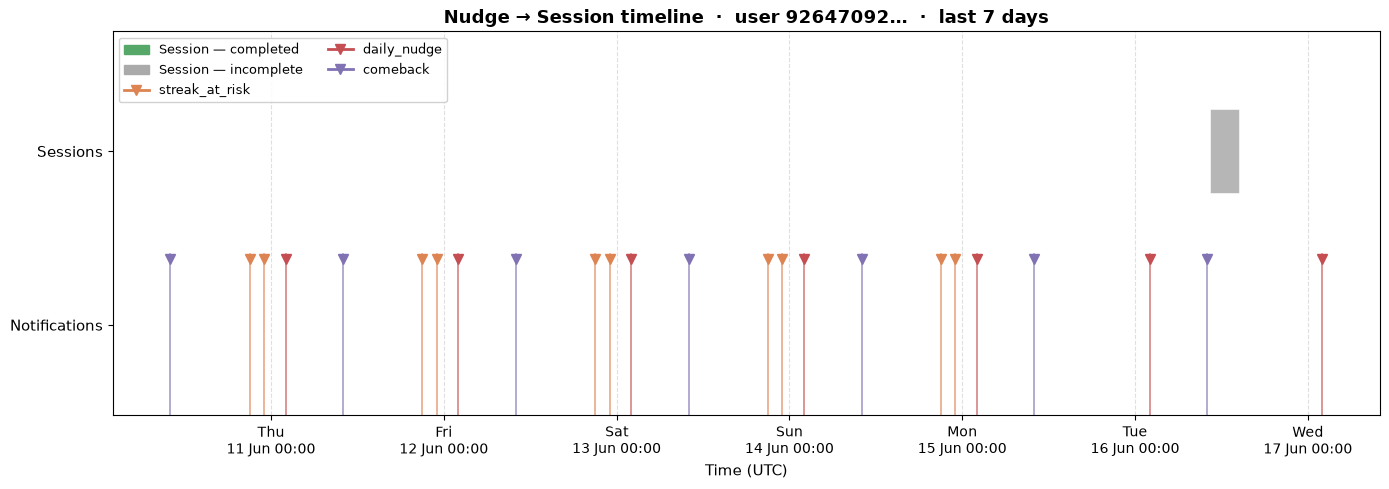

In [40]:
fig, ax = plt.subplots(figsize=(14, 5))

# ── Sessions as horizontal bars ──────────────────────────────────────────────
SESSION_Y   = 1.0   # centre y for the session lane
BAR_HEIGHT  = 0.35

for _, s in df_sessions.iterrows():
    start = s['started_at']
    end   = s['end']
    color = SESSION_COMPLETED_COLOR if s['completed'] else SESSION_INCOMPLETE_COLOR
    ax.barh(
        SESSION_Y,
        (end - start).total_seconds() / 3600,   # width in hours
        left=mdates.date2num(start.to_pydatetime()),
        height=BAR_HEIGHT,
        color=color,
        alpha=0.85,
        edgecolor='white',
        linewidth=0.5,
    )

# ── Notifications as vertical tick marks ─────────────────────────────────────
NOTIF_Y_BASE = 0.0   # bottom of the notif lane
NOTIF_Y_TOP  = 0.55  # how tall the tick rises

for _, n in df_notifs.iterrows():
    t     = n['created_at'].to_pydatetime()
    color = NOTIF_COLORS.get(n['type'], '#888888')
    ax.axvline(t, ymin=0.0, ymax=0.42, color=color, linewidth=1.2, alpha=0.7)
    ax.plot(t, NOTIF_Y_BASE + NOTIF_Y_TOP, marker='v', color=color,
            markersize=7, zorder=5)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.set_yticks([NOTIF_Y_BASE + NOTIF_Y_TOP / 2, SESSION_Y])
ax.set_yticklabels(['Notifications', 'Sessions'], fontsize=11)
ax.set_ylim(-0.1, 1.5)

ax.xaxis_date()   # tell matplotlib x-axis holds dates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a\n%d %b %H:%M'))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
fig.autofmt_xdate(rotation=0, ha='center')

ax.set_xlabel('Time (UTC)', fontsize=11)
ax.set_title(
    f'Nudge → Session timeline  ·  user {TARGET_USER_ID[:8]}…  ·  last {DAYS_BACK} days',
    fontsize=13, fontweight='bold'
)

# ── Legend ───────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=SESSION_COMPLETED_COLOR,  label='Session — completed'),
    mpatches.Patch(color=SESSION_INCOMPLETE_COLOR, label='Session — incomplete'),
]
legend_lines = [
    plt.Line2D([0], [0], color=c, linewidth=2, marker='v', markersize=7, label=t)
    for t, c in NOTIF_COLORS.items()
    if t in df_notifs['type'].values
]
ax.legend(
    handles=legend_patches + legend_lines,
    loc='upper left', fontsize=9, framealpha=0.9,
    ncol=2
)

ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

## 5 — Conversion table

For each nudge (`daily_nudge` or `streak_at_risk`), did a session start within 30 minutes?

In [41]:
NUDGE_TYPES = {'daily_nudge', 'streak_at_risk'}
WINDOW      = pd.Timedelta(minutes=30)

nudges = df_notifs[df_notifs['type'].isin(NUDGE_TYPES)].copy()

if nudges.empty or df_sessions.empty:
    print('Not enough data for conversion analysis.')
else:
    rows = []
    for _, n in nudges.iterrows():
        window_end = n['created_at'] + WINDOW
        hit = df_sessions[
            (df_sessions['started_at'] >= n['created_at']) &
            (df_sessions['started_at'] <= window_end)
        ]
        rows.append({
            'sent_at':          n['created_at'].strftime('%Y-%m-%d %H:%M'),
            'type':             n['type'],
            'converted':        len(hit) > 0,
            'sessions_in_30m':  len(hit),
        })

    df_conv = pd.DataFrame(rows)
    rate = df_conv['converted'].mean() * 100
    print(f'Nudges: {len(df_conv)}   |   Conversion rate (30 min window): {rate:.0f}%')
    display(df_conv)

Nudges: 17   |   Conversion rate (30 min window): 0%


,sent_at,type,converted,sessions_in_30m
0,2026-06-10 21:01,streak_at_risk,False,0
1,2026-06-10 23:01,streak_at_risk,False,0
2,2026-06-11 02:01,daily_nudge,False,0
3,2026-06-11 21:01,streak_at_risk,False,0
4,2026-06-11 23:01,streak_at_risk,False,0
5,2026-06-12 02:01,daily_nudge,False,0
6,2026-06-12 21:01,streak_at_risk,False,0
7,2026-06-12 23:01,streak_at_risk,False,0
8,2026-06-13 02:01,daily_nudge,False,0
9,2026-06-13 21:01,streak_at_risk,False,0
